# TP2 - Adaptation des modèles de fondation (Parameter-Efficient Fine-Tuning)

Dans ce TP, vous allez implémenter des adaptateurs pour une tâche de classification en histopathologie, en vous appuyant
sur un modèle auto-supervisé (DINOv2). Chaque fois que vous voyez un
bloc `##### START CODE #####`, complétez-le avec votre implémentation.

Il y a deux parties :

1. Implémenter les adaptateurs à partir de zéro: Bottleneck, AdaptFormer, LoRA, VeRA et le prompt-tuning.
   Figez le réseau de base et comparez-les. Au cours de cet exercice, nous examinerons également la structure de DINOv2
   et évaluerons le réseau de base pré-entraîné et figé comme référence.
2. PEFT : reproduire LoRA (et VeRA / IA3) à l’aide de la bibliothèque
   [`peft`](https://github.com/huggingface/peft) de Hugging Face.

Astuce: exécutez la cellule de comptage des paramètres après chaque adaptateur. La faible proportion de paramètres entraînables
est l’intérêt même de PEFT, il est donc utile de la vérifier à chaque fois.

## 0. Setup

In [1]:
# Core deps. peft/transformers are only needed for Part 2.
!pip3 install torchmetrics einops --quiet
!pip3 install "peft==0.13.2" "transformers>=4.40" --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import matplotlib.pyplot as plt

from einops import repeat
from tqdm.notebook import tqdm
from urllib.request import urlretrieve
from torch.utils.data import Subset, DataLoader

/Users/pierremarza/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
def set_seed(seed=0):
    """Seed the RNGs so runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 1. Modèle de fondation

Nous utilisons [DINOv2 (Oquab et al., 2023)](https://arxiv.org/abs/2304.07193), un modèle de fondation entrainé de façon auto-supervisée sur un large dataset d'images naturelles. Il s'agit d'un Vision Transformer (ViT).

![ViT architecture](https://viso.ai/wp-content/uploads/2021/09/vision-transformer-vit.png)

Pour des questions d'efficacité, nous utilisons la variante *small* (`vits`) dont la dimension est 384.


In [4]:
def build_dino(model_type='vits'):
    """
    Load a pretrained DINOv2 model.
        model_type [str]: one of vits, vitb, vitl, vitg
    returns a DinoVisionTransformer.
    """
    return torch.hub.load('facebookresearch/dinov2', f'dinov2_{model_type}14')


# Feature dimensions for each DINOv2 variant (handy when adding the probing head).
DINO_FEATURE_DIM = {'vits': 384, 'vitb': 768, 'vitl': 1024, 'vitg': 1536}

## 2. Dataset — PatchCamelyon (PCam)

PCam est un ensemble de patches histopathologiques RGB de 96 pixels × 96 pixels extraits d’images de lames entières de Camelyon,
chacun étant associé à une étiquette binaire (indiquant la présence ou non de tissu métastatique). Afin de garantir la rapidité de l’entraînement,
nous n’utilisons que le sous-ensemble de validation, que nous divisons ensuite à nouveau en sous-ensembles d’entraînement et de validation.

In [5]:
def download_from_url(url: str, filename: str):
    import requests
    import tqdm

    # User-Agent header is required by some servers (e.g., Zenodo) to allow downloads
    headers = {"User-Agent": "thunder-bench (https://github.com/MICS-Lab/thunder)"}
    with open(filename, "wb") as f:
        with requests.get(url, stream=True, headers=headers) as r:
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))

            # tqdm has many interesting parameters. Feel free to experiment!
            tqdm_params = {
                "desc": url,
                "total": total,
                "miniters": 1,
                "unit": "B",
                "unit_scale": True,
                "unit_divisor": 1024,
            }
            with tqdm.tqdm(**tqdm_params) as pb:
                for chunk in r.iter_content(chunk_size=8192):
                    pb.update(len(chunk))
                    f.write(chunk)

def ungzip_file(file_path: str, extract_dir: str):
    import gzip
    import shutil

    with gzip.open(file_path, "rb") as f_in:
        with open(extract_dir, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    os.remove(file_path)

urls = [
        (
            "https://zenodo.org/api/records/2546921/files/camelyonpatch_level_2_split_valid_x.h5.gz/content",
            "camelyonpatch_level_2_split_valid_x.h5",
        ),
        (
            "https://zenodo.org/api/records/2546921/files/camelyonpatch_level_2_split_valid_y.h5.gz/content",
            "camelyonpatch_level_2_split_valid_y.h5",
        ),
    ]


In [ ]:
os.makedirs('pcam', exist_ok=True)
for url, name in urls:
    if not os.path.exists(f"pcam/{name}"):
        download_from_url(url, f"pcam/content")
        ungzip_file(f"pcam/content", f"pcam/{name}")

In [7]:
# DINOv2 uses a patch size of 14, so the image side must be a multiple of 14.
frame_size = 98  # 98 = 7 * 14
dataset_transforms = transforms.Compose([
    transforms.Resize((frame_size, frame_size)),
    transforms.ToTensor(),
])
dataset = torchvision.datasets.PCAM('.', 'val', transform=dataset_transforms)
print('Total patches:', len(dataset))

Total patches: 32768


In [8]:
split_ratio = 0.7

indices = list(range(len(dataset)))
random.shuffle(indices)
split = int(split_ratio * len(indices))

train_dataset = Subset(dataset, indices[:split])
val_dataset = Subset(dataset, indices[split:])
print(f'train: {len(train_dataset)}  |  val: {len(val_dataset)}')

train: 22937  |  val: 9831


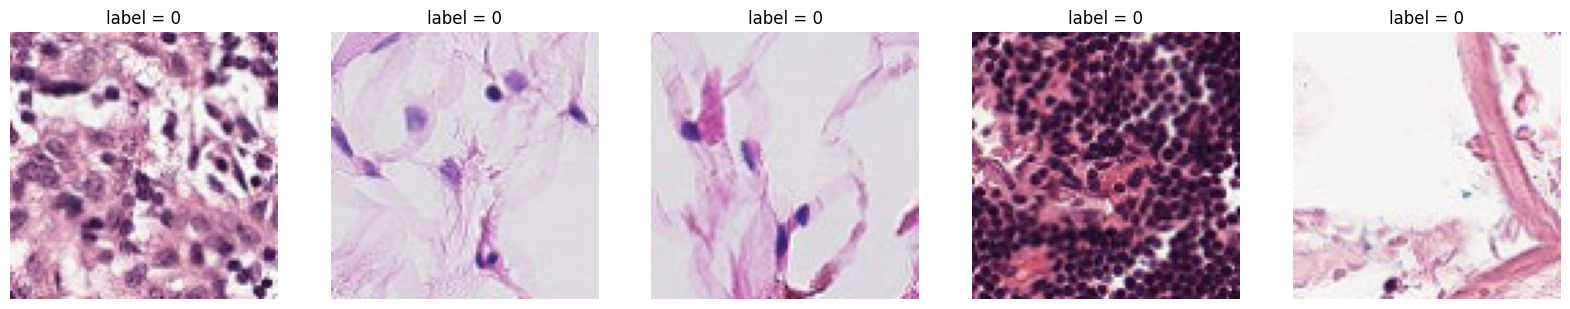

In [9]:
num_imgs = 5
fig, axs = plt.subplots(1, num_imgs, figsize=(4 * num_imgs, 4))
for i in range(num_imgs):
    img, label = train_dataset[i]
    axs[i].imshow(img.permute(1, 2, 0))
    axs[i].set_title(f'label = {label}')
    axs[i].axis('off')
plt.show()

## 3. Fonctions d'aide

We put a linear-probing head on top of the frozen backbone and train it together with
whatever adapter we insert. We also provide reusable training and parameter-counting
helpers.

Nous plaçons une tête de classification linéaire (*linear probe*) à la suite du modèle figé et l'entraînons conjointement avec
n'importe quel adaptateur que nous insérons. Nous fournissons également des outils réutilisables d'entraînement et de comptage des paramètres.

In [10]:
def add_linear_probing(model, feature_dim=384, num_classes=2):
    """
    Replace the model head with a linear classifier.
    For the binary case we output a single logit/probability (BCE).
    """
    out_dim = 1 if num_classes == 2 else num_classes
    final = nn.Sigmoid() if num_classes == 2 else nn.Softmax(dim=-1)
    model.head = nn.Sequential(nn.Linear(feature_dim, out_dim), final)
    return model

In [11]:
def count_parameters(model):
    """Return (trainable, total) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def report_parameters(model, name=''):
    trainable, total = count_parameters(model)
    print(f'{name+": " if name else ""}{trainable:,} trainable / {total:,} total '
          f'({100 * trainable / total:.2f}%)')
    return trainable, total

In [12]:
@torch.no_grad()
def _gather(metric_fns, preds, labels):
    preds = torch.tensor(preds)
    labels = torch.tensor(labels)
    return {k: fn(preds, labels).item() for k, fn in metric_fns.items()}


def train_model(model, train_dataloader, val_dataloader, optimizer, criterion,
                device, num_epochs=10):
    """Train `model` and return a per-epoch history dict."""
    model.to(device)
    metric_fns = {'F1': torchmetrics.F1Score('binary'),
                  'AUC': torchmetrics.AUROC('binary')}
    history = {'train_loss': [], 'val_loss': [],
               'train_F1': [], 'val_F1': [], 'train_AUC': [], 'val_AUC': []}

    for epoch in range(num_epochs):
        # ---- train ----
        model.train()
        losses, labels, preds = [], [], []
        for x, y in tqdm(train_dataloader, leave=False, desc=f'train {epoch+1}/{num_epochs}'):
            optimizer.zero_grad()
            out = model(x.to(device))
            loss = criterion(out, y.to(device).float().unsqueeze(-1))
            loss.backward()
            optimizer.step()
            losses.append(loss.item() * len(y))
            labels.extend(y.cpu().unsqueeze(-1).tolist())
            preds.extend(out.detach().cpu().tolist())
        tr = _gather(metric_fns, preds, labels)
        tr_loss = sum(losses) / len(labels)

        # ---- val ----
        model.eval()
        losses, labels, preds = [], [], []
        for x, y in tqdm(val_dataloader, leave=False, desc=f'val {epoch+1}/{num_epochs}'):
            with torch.no_grad():
                out = model(x.to(device))
            loss = criterion(out, y.to(device).float().unsqueeze(-1))
            losses.append(loss.item() * len(y))
            labels.extend(y.cpu().unsqueeze(-1).tolist())
            preds.extend(out.cpu().tolist())
        va = _gather(metric_fns, preds, labels)
        va_loss = sum(losses) / len(labels)

        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_F1'].append(tr['F1']);  history['val_F1'].append(va['F1'])
        history['train_AUC'].append(tr['AUC']); history['val_AUC'].append(va['AUC'])

        print(f'[{epoch+1:2d}/{num_epochs}] '
              f'train loss {tr_loss:.4f} F1 {tr["F1"]:.4f} AUC {tr["AUC"]:.4f} | '
              f'val loss {va_loss:.4f} F1 {va["F1"]:.4f} AUC {va["AUC"]:.4f}')

    return history

## 3b. Inspection de DINOv2

Avant de modifier le réseau, il est utile de comprendre comment un ViT DINOv2 est réellement construit. Les
adaptateurs ci-dessous ciblent des sous-modules spécifiques (les projections d’attention `qkv`/`proj`, le
`mlp` par bloc, les normes de couche `norm1`/`norm2`, les tokens préfixés) ; ainsi, savoir où
ils se trouvent permet de mieux comprendre les fonctions d’insertion.

Nous affichons trois éléments :

1. la structure de haut niveau (intégration du patch, la séquences de `blocks` du Transformer, la norme finale/tête),
2. la structure d’un seul bloc d’encodeur, qui est l’unité répétitive que nous adaptons,
3. un résumé des paramètres nommés, afin de voir quels tenseurs existent et quelle est leur taille.

In [14]:
# Build a fresh small backbone just for inspection.
dino = build_dino('vits')

print('=== Top-level modules ===')
for name, module in dino.named_children():
    # For the block list, show how many blocks there are rather than all of them.
    if name == 'blocks':
        print(f'{name:<16} ModuleList of {len(module)} transformer blocks')
    else:
        print(f'{name:<16} {module.__class__.__name__}')

print(f'\nDepth (number of blocks): {len(dino.blocks)}')
print(f'Embedding / feature dim : {dino.norm.normalized_shape[0]}')

Using cache found in /Users/pierremarza/.cache/torch/hub/facebookresearch_dinov2_main
/Users/pierremarza/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")


TypeError: unsupported operand type(s) for |: 'type' and 'NoneType'

In [ ]:
# Detailed layout of a SINGLE encoder block — this is the unit every adapter modifies.
print('=== One encoder block (dino.blocks[0]) ===')
print(dino.blocks[0])

In [ ]:
# Named-parameter summary for one block, so we can see the exact tensor names
# the freeze functions will match against (e.g. "attn.qkv", "mlp.fc1", "norm1").
print('=== Parameters of dino.blocks[0] ===')
for name, p in dino.blocks[0].named_parameters():
    print(f'{name:<28} {tuple(p.shape)}')

# Quick sanity check of the pieces the adapters rely on.
block = dino.blocks[0]
print('\nKey submodules used by the adapters:')
print('  attn.qkv  :', block.attn.qkv)    # fused Q,K,V projection  -> LoRA / VeRA
print('  attn.proj :', block.attn.proj)   # attention output proj   -> Bottleneck
print('  mlp.fc1   :', block.mlp.fc1)     # MLP hidden              -> AdaptFormer / Bottleneck
print('  norm1     :', block.norm1)       # pre-attention layernorm
print('  norm2     :', block.norm2)       # pre-MLP layernorm       -> folded into AdaptFormer

del dino  # free the inspection model

## 4. Adapteurs (implémentation)

Les adaptateurs sont de petits modules insérés dans une architecture pré-entraînée. L'idée est d'éviter
le réajustement de l'ensemble du modèle, ce qui impliquerait d'entraîner un grand nombre de paramètres et risquerait
de perdre ce qui a été appris lors du pré-entraînement. Lorsque l'on entraîne un adaptateur, l'architecture de base est
gelée, à l'exception de l'adaptateur inséré (et, pour certaines méthodes, des *layer norms*).

Pour chaque adaptateur, nous définissons trois éléments : le module adaptateur, la fonction d’insertion et
la fonction de gel.

### 4.1. Bottleneck adapter

Le [bottleneck adapter](https://arxiv.org/abs/1902.00751) ajoute un adapteur de 2 couches à 2 positions dans chaque bloc du Transformer. Pour cette méthode, les *layer norms* ne sont pas figées.

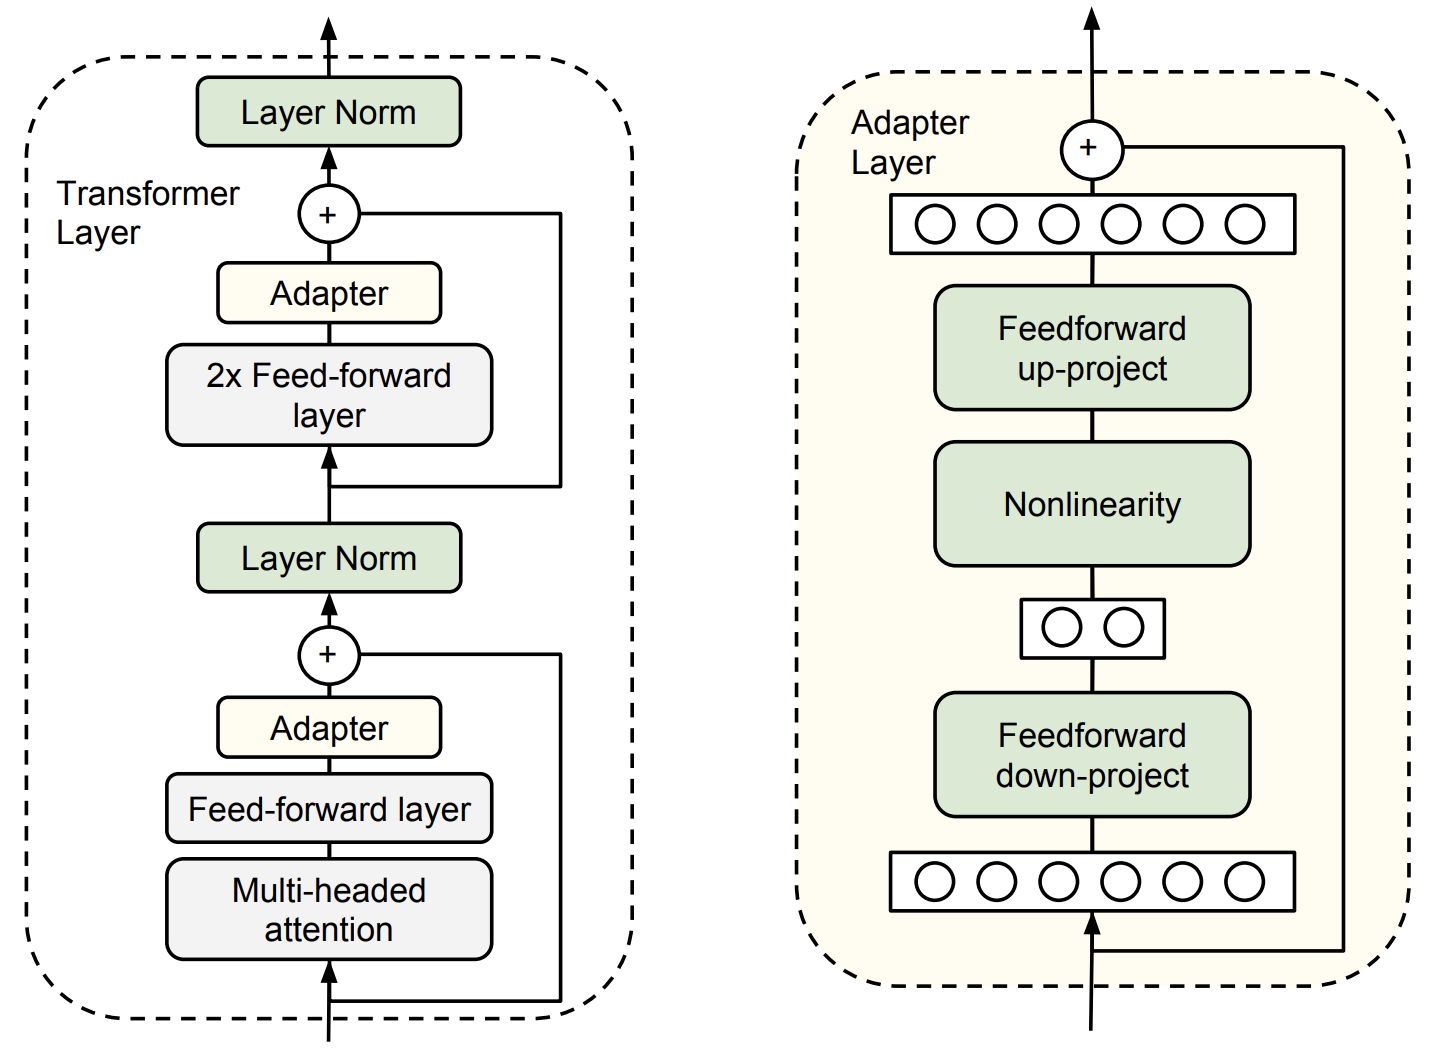

In [ ]:
class BottleneckAdapter(nn.Module):
    def __init__(self, in_dim, activation='ReLU', reduction_factor=16):
        super().__init__()
        hidden_dim = in_dim // reduction_factor
        self.adapter_downsample = nn.Linear(in_dim, hidden_dim)
        self.activation = getattr(nn, activation)()
        self.adapter_upsample = nn.Linear(hidden_dim, in_dim)
        # Zero-init the up-projection so the adapter starts as identity.
        nn.init.zeros_(self.adapter_upsample.weight)
        nn.init.zeros_(self.adapter_upsample.bias)

    def forward(self, x_in):
        x = self.adapter_downsample(x_in)
        x = self.activation(x)
        x = self.adapter_upsample(x)
        return x + x_in

In [ ]:
def add_bottleneck_adapter(model):
    for block in model.blocks:
        block.attn.proj = nn.Sequential(block.attn.proj,
                                        BottleneckAdapter(block.attn.proj.out_features))
        block.mlp = nn.Sequential(block.mlp,
                                  BottleneckAdapter(block.mlp.fc2.out_features))

In [ ]:
def freeze_model_bottleneck(model):
    for name, param in model.named_parameters():
        # Keep adapters + layer norms trainable.
        if not ('adapter' in name or 'norm1' in name or 'norm2' in name):
            param.requires_grad = False

### 4.2. AdaptFormer

[AdaptFormer](https://arxiv.org/abs/2205.13535) est similaire, mais inséré une fois par bloc and placé en parallèle de la branch MLP pré-entrainée. Ici, les *layer norms* restent figées.

![AdaptFormer](https://d3i71xaburhd42.cloudfront.net/2fe2f849b94cf08b559226bc9d78adcaef5ef186/4-Figure2-1.png)

In [ ]:
class AdaptFormer(nn.Module):
    def __init__(self, layer_norm, linear, activation='ReLU', reduction_factor=8):
        super().__init__()
        self.layer_norm = layer_norm
        self.linear = linear
        self.adapter_alpha = nn.Parameter(torch.ones(1))

        in_dim = self.linear.fc2.out_features
        hidden_dim = in_dim // reduction_factor
        self.adapter_downsample = nn.Linear(in_dim, hidden_dim)
        self.activation = getattr(nn, activation)()
        self.adapter_upsample = nn.Linear(hidden_dim, in_dim)
        nn.init.zeros_(self.adapter_upsample.weight)
        nn.init.zeros_(self.adapter_upsample.bias)

    def forward(self, x):
        main_x = self.linear(self.layer_norm(x))
        adapted_x = self.adapter_upsample(self.activation(self.adapter_downsample(x)))
        return main_x + self.adapter_alpha * adapted_x

In [ ]:
def add_adaptformer(model):
    for block in model.blocks:
        # Fold the (frozen) norm2 into the adapter wrapper, replace it by identity.
        block.mlp = AdaptFormer(block.norm2, block.mlp)
        block.norm2 = nn.Identity()

In [ ]:
def freeze_model_adaptformer(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

### 4.3. LoRA

[LoRA (low-rank adaptation)](https://arxiv.org/abs/2106.09685) 
intervient sur les branches *query* et *value* de l'attention, en parallèle avec la projection principale, sans activation et avec des matrices à rang faible entrainables (*learnable low-rank matrices*) sans biais. L'hyperparamètre de scaling $\alpha$ est fixé.

$$x_{\text{out}} = \text{Linear}(x) + \alpha\,(x\,W_d\,W_u),\quad
  W_d\in\mathbb R^{d\times r},\; W_u\in\mathbb R^{r\times d}$$

Dans un ViT, la projection `qkv` est fusionnée, donc on ajoute LoRA aux Q et V et pas à K.

![LoRA](https://miro.medium.com/v2/resize:fit:299/1*BCs63SXaAu3NKqUaTLTH2g.png)


In [ ]:
class LoRA(nn.Module):
    def __init__(self, linear_layer, in_dim, rank=32, alpha=16):
        super().__init__()
        self.linear_layer = linear_layer
        std = 1.0 / torch.sqrt(torch.tensor(rank).float())
        # W_d is random, W_u is zero, so the product starts at zero.
        self.adapter_Q_downsample = nn.Parameter(torch.randn(in_dim, rank) * std)
        self.adapter_Q_upsample = nn.Parameter(torch.zeros(rank, in_dim))
        self.adapter_V_downsample = nn.Parameter(torch.randn(in_dim, rank) * std)
        self.adapter_V_upsample = nn.Parameter(torch.zeros(rank, in_dim))
        self.adapter_alpha = alpha

    def forward(self, x):
        x_q = self.adapter_alpha * (x @ self.adapter_Q_downsample @ self.adapter_Q_upsample)
        x_v = self.adapter_alpha * (x @ self.adapter_V_downsample @ self.adapter_V_upsample)
        x_lora = torch.cat([x_q, torch.zeros_like(x_v), x_v], dim=-1)  # [Q | K | V]
        return self.linear_layer(x) + x_lora

In [ ]:
def add_lora(model, rank=32, alpha=16):
    for block in model.blocks:
        block.attn.qkv = LoRA(block.attn.qkv, block.attn.qkv.in_features,
                              rank=rank, alpha=alpha)

In [ ]:
def freeze_model_lora(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

### 4.4. VeRA

[VeRA (vector-based random matrix adaptation)](https://arxiv.org/abs/2310.11454) est proche de LoRA, avec cependant les matrices $A, B$ aléatoires, fixées et partagées entre couches. Uniquement les vectors de scaling $d$ (longueur $r$) et $b$ (longueur $d$) sont entrainés:

$$\Delta x = \alpha\,\big((x\,A)\odot d\big)\,B \odot b.$$

Cela rend VeRA beaucoup plus efficace en terme de paramètres optimisés que LoRA.

<img src="https://storage.googleapis.com/zenn-user-upload/19a06e60f7b1-20231022.png" width="400"/>


In [ ]:
class VeRA(nn.Module):
    def __init__(self, linear_layer, in_dim,
                 q_downsample, v_downsample, q_upsample, v_upsample,
                 rank=32, alpha=16):
        super().__init__()
        self.linear_layer = linear_layer
        # Shared, frozen random projections (registered as buffers, not parameters).
        self.register_buffer('q_downsample', q_downsample)
        self.register_buffer('v_downsample', v_downsample)
        self.register_buffer('q_upsample', q_upsample)
        self.register_buffer('v_upsample', v_upsample)
        self.alpha = alpha

        # Trainable scaling vectors. d ~ small positive, b starts at 0.
        self.adapter_qd = nn.Parameter(torch.empty(rank).uniform_(1e-5, 1.0))
        self.adapter_vd = nn.Parameter(torch.empty(rank).uniform_(1e-5, 1.0))
        self.adapter_qb = nn.Parameter(torch.zeros(in_dim))
        self.adapter_vb = nn.Parameter(torch.zeros(in_dim))

    def forward(self, x):
        # x: [B, L, d]. d-vectors scale the rank dim, b-vectors scale the output dim.
        x_q = self.alpha * (((x @ self.q_downsample) * self.adapter_qd)
                            @ self.q_upsample) * self.adapter_qb
        x_v = self.alpha * (((x @ self.v_downsample) * self.adapter_vd)
                            @ self.v_upsample) * self.adapter_vb
        x_lora = torch.cat([x_q, torch.zeros_like(x_v), x_v], dim=-1)
        return self.linear_layer(x) + x_lora

In [ ]:
def add_vera(model, rank=32):
    in_dim = model.norm.normalized_shape[0]

    # One set of shared random matrices for the whole network.
    q_downsample = torch.empty(in_dim, rank)
    v_downsample = torch.empty(in_dim, rank)
    q_upsample = torch.empty(rank, in_dim)
    v_upsample = torch.empty(rank, in_dim)
    for t in (q_downsample, v_downsample, q_upsample, v_upsample):
        nn.init.kaiming_uniform_(t)

    for block in model.blocks:
        block.attn.qkv = VeRA(block.attn.qkv, block.attn.qkv.in_features,
                              q_downsample, v_downsample, q_upsample, v_upsample,
                              rank=rank)

In [ ]:
def freeze_model_vera(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

### 4.5. Visual prompt tuning

Il ne s'agit pas vraiment d'un adapteur. Le [Visual prompt tuning](https://arxiv.org/pdf/2203.12119.pdf) fige tous les paramètres du modèle pré-entrainé et n'apprend qu'un esemble de *prompt tokens* ajoutés en début de la séquence d'entrée, soit uniquement pour la première couche ou à chaque couche hormis la dernière.

<img src="https://img-blog.csdnimg.cn/fe4b4591fd624532a6de5d898b5c1ead.png" width="800"/>

In [ ]:
class PromptTuning(nn.Module):
    def __init__(self, num_tokens, token_dim=384):
        super().__init__()
        self.num_tokens = num_tokens
        self.adapter_prompts = nn.Parameter(torch.randn(num_tokens, token_dim) * 0.02)

    def forward(self, x):
        prompts = self.adapter_prompts.unsqueeze(0).expand(x.shape[0], -1, -1)
        return torch.cat([prompts, x], dim=1)

In [ ]:
def add_prompttuning(model, all_layers=True, num_tokens=128):
    token_dim = model.norm.normalized_shape[0]
    num_layers = len(model.blocks) - 1 if all_layers else 1
    for block_id in range(num_layers):
        model.blocks[block_id] = nn.Sequential(
            PromptTuning(num_tokens, token_dim), model.blocks[block_id])

In [ ]:
def freeze_model_prompttuning(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

## 4b. Baseline: DINOv2 sur PCam sans adaptation

DINOv2 a été pré-entraîné sur des images naturelles, et non sur des images histlogiques. Avant d’ajouter un adaptateur,
vérifions dans quelle mesure le modèle de base pré-entraîné et gelé se transpose déjà à PCam.

Nous gelons tous les paramètres de l’architecture de base et entraînons uniquement un classifieur linéaire sur le CLS token.
Il s’agit de l’évaluation standard par sondage linéaire (*linear probing*) d’un modèle pré-entrainé, et c’est notre limite inférieure: tout adaptateur devrait la dépasser. Entraîner une tête linéaire sur des features gelés est la manière la plus équitable d’évaluer la qualité de la représentation sans modifier l’architecture de base.

In [ ]:
BATCH_SIZE = 16
NUM_EPOCHS = 3
OPTIMIZER_TYPE = 'Adam'
BASE_LR = 3e-4
CRITERION_TYPE = 'BCELoss'

In [ ]:
def build_frozen_baseline():
    """Frozen DINOv2 backbone + trainable linear-probing head (no adapter)."""
    model = build_dino('vits')
    for p in model.parameters():        # freeze the whole backbone
        p.requires_grad = False
    add_linear_probing(model, feature_dim=DINO_FEATURE_DIM['vits'])  # the head stays trainable
    return model

set_seed(0)
baseline_model = build_frozen_baseline()
report_parameters(baseline_model, 'frozen DINOv2 + linear probe')

In [ ]:
# Train ONLY the linear head on top of the frozen, natural-image features.
set_seed(0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, baseline_model.parameters()), lr=BASE_LR)
criterion = nn.BCELoss()

baseline_history = train_model(baseline_model, train_loader, val_loader,
                               optimizer, criterion, device, num_epochs=NUM_EPOCHS)

best_auc = max(baseline_history['val_AUC'])
best_f1 = max(baseline_history['val_F1'])
print(f'\nFrozen-backbone baseline — best val AUC {best_auc:.4f} | best val F1 {best_f1:.4f}')

In [ ]:
def plot_results(results):
    """Plot validation AUC/F1 curves for every trained adapter."""
    if not results:
        print('No results to plot yet — run the training cell above.')
        return
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    for adapter, h in results.items():
        epochs = range(1, len(h['val_AUC']) + 1)
        axs[0].plot(epochs, h['val_AUC'], marker='o', label=adapter)
        axs[1].plot(epochs, h['val_F1'], marker='o', label=adapter)
    axs[0].set_title('Validation AUC'); axs[1].set_title('Validation F1')
    for ax in axs:
        ax.set_xlabel('epoch'); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()


In [ ]:
# Keep the baseline alongside the adapters so it shows up in the final comparison.
results = {'frozen (no adapter)': baseline_history}
param_stats = {'frozen (no adapter)': count_parameters(baseline_model)}

plot_results(results)

## 5. Entrainement and comparaison

Nous encapsulons les opérations d'insertion et de gel dans des fonctions de traitement, puis nous entraînons chaque adaptateur et recueillons les résultats en vue d'une comparaison finale.

In [ ]:
ADAPTER_TYPES = ['bottleneck', 'adaptformer', 'lora', 'vera', 'prompttuning']

ADD_FN = {
    'bottleneck':   add_bottleneck_adapter,
    'adaptformer':  add_adaptformer,
    'lora':         add_lora,
    'vera':         add_vera,
    'prompttuning': add_prompttuning,
}
FREEZE_FN = {
    'bottleneck':   freeze_model_bottleneck,
    'adaptformer':  freeze_model_adaptformer,
    'lora':         freeze_model_lora,
    'vera':         freeze_model_vera,
    'prompttuning': freeze_model_prompttuning,
}

def add_adapter(model, adapter_type):
    assert adapter_type in ADAPTER_TYPES
    ADD_FN[adapter_type](model)

def freeze_model(model, adapter_type):
    assert adapter_type in ADAPTER_TYPES
    FREEZE_FN[adapter_type](model)

In [ ]:
BATCH_SIZE = 16
NUM_EPOCHS = 3
OPTIMIZER_TYPE = 'Adam'
BASE_LR = 3e-4
CRITERION_TYPE = 'BCELoss'

# Choose which adapters to run. Use the full list for the final comparison.
RUN_ADAPTERS = ['vera']  # e.g. ADAPTER_TYPES

In [ ]:
# Keep any baseline already in `results` (see Section 4b); just add the adapters.
results = dict(results) if 'results' in globals() else {}
param_stats = dict(param_stats) if 'param_stats' in globals() else {}

for adapter in RUN_ADAPTERS:
    print(f'\n=== Training adapter: {adapter} ===')
    set_seed(0)

    lr = BASE_LR / 10 if adapter == 'lora' else BASE_LR

    model = build_dino('vits')
    add_adapter(model, adapter)
    freeze_model(model, adapter)
    param_stats[adapter] = report_parameters(model, adapter)

    add_linear_probing(model, feature_dim=DINO_FEATURE_DIM['vits'])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    optimizer = getattr(torch.optim, OPTIMIZER_TYPE)(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = getattr(nn, CRITERION_TYPE)()

    results[adapter] = train_model(model, train_loader, val_loader,
                                   optimizer, criterion, device, num_epochs=NUM_EPOCHS)

In [ ]:
# Summary table: best val AUC/F1 vs. parameter cost.
if results:
    print(f'{"adapter":<14}{"best AUC":>10}{"best F1":>10}{"trainable":>14}{"% params":>10}')
    print('-' * 58)
    for a in results:
        best_auc = max(results[a]['val_AUC'])
        best_f1 = max(results[a]['val_F1'])
        tr, tot = param_stats[a]
        print(f'{a:<14}{best_auc:>10.4f}{best_f1:>10.4f}{tr:>14,}{100*tr/tot:>9.2f}%')

---

## 6. Partie 2 — Adapteurs avec Hugging Face PEFT

Implémenter chaque adaptateur à la main est utile pour en comprendre le fonctionnement, mais dans la pratique, vous vous tournerez plutôt vers [`peft`](https://github.com/huggingface/peft), qui fournit des implémentations prêtes à l’emploi de LoRA, VeRA, AdaLoRA, IA3, le réglage des prompts et bien plus encore. Il fonctionne sur n’importe quel `nn.Module`, et pas seulement sur les modèles Hugging Face, en ciblant les couches par leur nom.

Ci-dessous, nous refaisons l’expérience LoRA de la partie 1 avec PEFT, puis nous montrons à quel point il suffit de peu de modifications pour passer à VeRA et IA3.

### 6.1. Inspecter les couches cibles

PEFT injecte des adapteurs dans les modules appelés `nn.Linear`. Pour un ViT DINOv2, les couches cibles sont les couches d'attentions `qkv` et `proj` ainsi que le MLP `fc1`/`fc2`. Listons les noms des modules pour savoir quoi cibler.

In [ ]:
from peft import LoraConfig, VeraConfig, IA3Config, get_peft_model

# Build a fresh backbone and peek at some linear layer names.
peft_backbone = build_dino('vits')
linear_names = [n for n, m in peft_backbone.named_modules() if isinstance(m, nn.Linear)]
print('Example Linear modules:')
for n in linear_names[:8]:
    print(' ', n)
print('...')
print('total linear layers:', len(linear_names))

### 6.2. Enaspulation de DINOv2 + tête de classification

PEFT encapsule un seul `nn.Module` ; nous regroupons donc l'architecture de base et la tête linéaire dans un seul module. De cette manière, le classificateur est entraîné en même temps que les paramètres LoRA. Nous indiquons à PEFT
de conserver la tête entraînable via `modules_to_save`. 

In [ ]:
class DinoClassifier(nn.Module):
    """DINOv2 backbone (PEFT will adapt it) + a binary linear-probing head."""
    def __init__(self, backbone, feature_dim=384):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.Linear(feature_dim, 1), nn.Sigmoid())

    def forward(self, x):
        feats = self.backbone(x)          # CLS features [B, feature_dim]
        return self.head(feats)

### 6.3. LoRA avec PEFT

Un objet `LoraConfig` permet de définir le rang `r`, le coefficient de scaling `lora_alpha` et les modules ciblés. `target_modules=[« qkv »]` correspond à toutes les projections d'attention `qkv` par leur nom, ce qui correspond exactement
à l'endroit où nous avions apporté une modification manuelle dans la première partie. La fonction `get_peft_model` se charge de figer tous les autres éléments à notre place.

In [ ]:
def build_peft_lora_model(r=32, alpha=16, target_modules=("qkv",)):
    set_seed(0)
    backbone = build_dino('vits')
    config = LoraConfig(
        r=r,
        lora_alpha=alpha,
        target_modules=list(target_modules),
        lora_dropout=0.0,
        bias='none',
    )
    backbone = get_peft_model(backbone, config)
    model = DinoClassifier(backbone, feature_dim=DINO_FEATURE_DIM['vits'])
    return model

peft_lora = build_peft_lora_model()
# PEFT's own report (backbone only):
peft_lora.backbone.print_trainable_parameters()
# Full model including the head:
report_parameters(peft_lora, 'PEFT-LoRA (with head)')

Entrainons le maintenant avec la même `train_model` boucle que nous avons utilisé dans la partie 1.

In [ ]:
set_seed(0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, peft_lora.parameters()), lr=3e-4)
criterion = nn.BCELoss()

peft_history = train_model(peft_lora, train_loader, val_loader,
                           optimizer, criterion, device, num_epochs=NUM_EPOCHS)

In [ ]:
# Compare our hand-written LoRA (if available) with the PEFT version.
compare = {}
if 'lora' in results:
    compare['lora (scratch)'] = results['lora']
compare['lora (peft)'] = peft_history
plot_results(compare)

### 6.4. Changer la méthode: VeRA et IA3

Avec PEFT, changer de méthode revient à changer l'objet de configuration ; le code d'apprentissage ne change pas.

- VeRA partage des matrices aléatoires gelées entre les couches et entraîne de petits vecteurs de scaling.
- IA3 entraîne encore moins de paramètres: des vecteurs de rescaling par *feature* sur des projections sélectionnées.

In [ ]:
def build_peft_model(method='vera'):
    set_seed(0)
    backbone = build_dino('vits')
    if method == 'vera':
        config = VeraConfig(r=32, target_modules=['qkv'], vera_dropout=0.0)
    elif method == 'ia3':
        # IA3 needs to know which targets are "feedforward" (scaled on the output).
        config = IA3Config(target_modules=['qkv', 'fc2'],
                           feedforward_modules=['fc2'])
    else:
        raise ValueError(method)
    backbone = get_peft_model(backbone, config)
    return DinoClassifier(backbone, feature_dim=DINO_FEATURE_DIM['vits'])

for method in ['vera', 'ia3']:
    m = build_peft_model(method)
    report_parameters(m, f'PEFT-{method.upper()}')

In [ ]:
# Train one of them end-to-end (VeRA shown here).
peft_vera = build_peft_model('vera')
set_seed(0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, peft_vera.parameters()), lr=3e-4)
criterion = nn.BCELoss()

peft_vera_history = train_model(peft_vera, train_loader, val_loader,
                                optimizer, criterion, device, num_epochs=NUM_EPOCHS)

### 6.5. Sauvegarder and charger les adapteurs

Un avantage pratique: PEFT n'enregistre que les poids des adaptateurs (quelques centaines de Ko), et non l'architecture complète. Vous pouvez ainsi fournir de nombreux adaptateurs spécifiques à une tâche pour un seul modèle partagé.

In [ ]:
# Save just the adapter (backbone weights are NOT duplicated).
peft_lora.backbone.save_pretrained('dino_lora_pcam')
print('Saved files:', os.listdir('dino_lora_pcam'))

# To reload later:
#   from peft import PeftModel
#   backbone = build_dino('vits')
#   backbone = PeftModel.from_pretrained(backbone, 'dino_lora_pcam')

### 6.6. Conclusion

- Même principe, moins de code. `LoraConfig` + `get_peft_model` reproduit notre LoRA manuel en quelques lignes et fige le backbone à notre place.
- La méthode équivaut à la configuration. Passer à VeRA ou IA3 ne modifie que l’objet de configuration.
- Ciblage par nom. `target_modules` sélectionne les couches `nn.Linear` à adapter, les mêmes couches que celles que nous avions modifiées manuellement.
- Petits points de contrôle. Les adaptateurs sont sérialisés séparément, indépendamment du réseau de base, ce qui permet à un seul modèle de base de servir à de nombreuses tâches.

Dans la continuité, vous pourriez parcourir plusieurs méthodes PEFT, comme nous l’avons fait dans la partie 1, et tracer toutes les courbes de validation ensemble afin de comparer la précision par rapport au coût en paramètres.